In [1]:
import numpy as np
import MDAnalysis as mda
import os
import pandas as pd
from code_libraries.bilayer_operations import Bilayer
from code_libraries.acyl_chain_preprocessing import *
import matplotlib.pyplot as plt

In [2]:
start_frame , stop_frame = 0 , 500

In [3]:
pure_dopc = Bilayer("dopc_pure" , "sym" , start_frame , stop_frame)
pure_dopc.create_universe()
dopc_60 = Bilayer("dopc_60" , "sym" , start_frame , stop_frame)
dopc_60.create_universe()

pure_dopc.position_directory

'../heavy_data_NO_GIT/position_npys/'

## Area per lipid and bilayer thickness

In [5]:
pure_dopc.cleave_leaflets()
dopc_60.cleave_leaflets()

In [6]:
pure_dopc_apl = pure_dopc.area_per_lipid()
dopc_60_apl = dopc_60.area_per_lipid()

pure_dopc_blt = pure_dopc.total_bilayer_height()
dopc_60_blt = dopc_60.total_bilayer_height()

In [7]:
pure_dopc_apl

array([0.67987679, 0.6838954 , 0.68695407, 0.68107949, 0.67926774,
       0.67486368, 0.67339744, 0.67179914, 0.66960913, 0.67025424,
       0.66942895, 0.67309779, 0.6736234 , 0.67461704, 0.67456626,
       0.67304131, 0.6755126 , 0.67679152, 0.6751897 , 0.67348741,
       0.67143374, 0.67433618, 0.67121363, 0.66897388, 0.67111258,
       0.67110939, 0.67534813, 0.67852312, 0.6697989 , 0.67204934,
       0.67218583, 0.67240482, 0.6719573 , 0.6739008 , 0.67179518,
       0.66910929, 0.66811411, 0.6677907 , 0.66913757, 0.66828024,
       0.66410388, 0.66612344, 0.66436242, 0.66517824, 0.66491293,
       0.664709  , 0.6625439 , 0.66695751, 0.66799064, 0.66985638,
       0.66758225, 0.66307134, 0.6693302 , 0.67097786, 0.6684334 ,
       0.66848192, 0.66785242, 0.66719256, 0.66860951, 0.67214957,
       0.66978386, 0.67126786, 0.67221213, 0.6736119 , 0.67343693,
       0.67460681, 0.67732613, 0.67204526, 0.6692837 , 0.67170073,
       0.67238771, 0.67190509, 0.66869878, 0.66985829, 0.66884

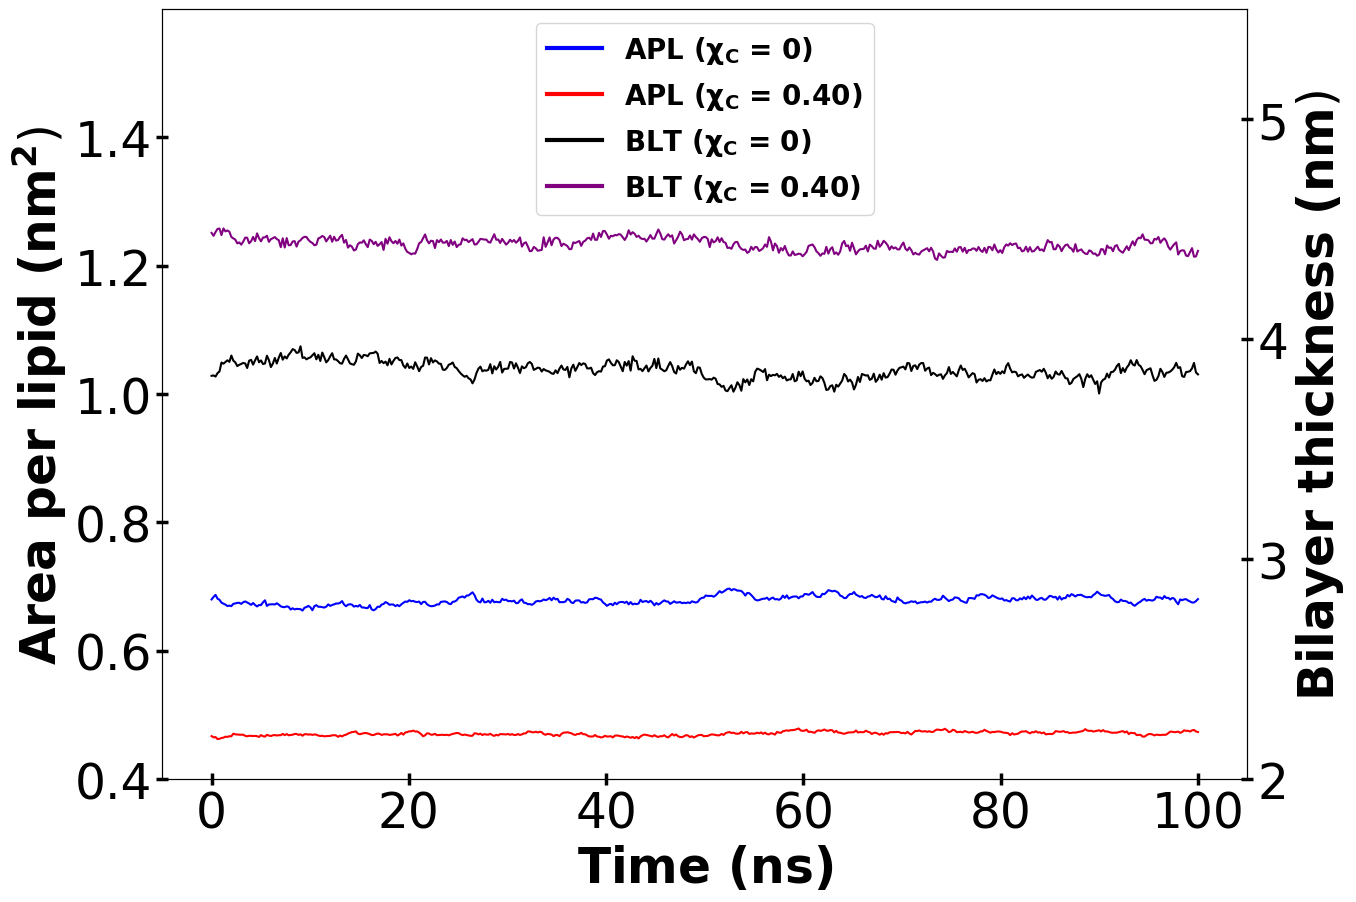

In [8]:
# plt.rcParams['font.weight'] = 'bold'
# plt.rcParams['axes.labelweight'] = 'bold'
# plt.rcParams['axes.titleweight'] = 'bold'
fig, ax1 = plt.subplots(figsize=(14,10))
ts = np.linspace(0, 100, stop_frame)
# Left axis: Area per lipid
ax1.plot(ts, pure_dopc_apl, color="blue", label=r"APL ($\mathbf{\chi_{C}}$ = 0)")
ax1.plot(ts, dopc_60_apl, color="red", label=r"APL ($\mathbf{\chi_{C}}$ = 0.40)")
ax1.set_xlabel(r"Time ($\mathbf{ns}$)", fontsize=35, fontweight='bold')
ax1.set_ylabel(r"Area per lipid ($\mathbf{nm^2})$", fontsize=35, fontweight='bold')
ax1.set_ylim(0.4, 1.6)
ax1.set_yticks([0.4 , 0.6 , 0.8 , 1.0 , 1.2 , 1.4])
ax1.tick_params(axis='both', which='major', labelsize=35 , width = 2.5 , length = 8 , direction = "inout")
# Create right axis for bilayer thickness
ax2 = ax1.twinx()
ax2.plot(ts, pure_dopc_blt, color="black", label=r"BLT ($\mathbf{\chi_{C}}$ = 0)")
ax2.plot(ts, dopc_60_blt, color="purple", label=r"BLT ($\mathbf{\chi_{C}}$ = 0.40)")
ax2.set_ylabel(r"Bilayer thickness ($\mathbf{nm})$", fontsize=35, fontweight='bold')
ax2.set_ylim(2, 5.5)
ax2.set_yticks([2 , 3 , 4 , 5])
ax2.tick_params(axis='both', which='major', labelsize=35 , width = 2.5 , length = 8 , direction = "inout")
# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
legend = ax1.legend(lines1 + lines2, labels1 + labels2, loc=9, fontsize=18, prop={'weight':'bold' , 'size': 20})
for line in legend.get_lines():
    line.set_linewidth(3.0)
plt.show()

In [12]:
np.mean(pure_dopc_blt) , np.std(pure_dopc_blt) , np.mean(dopc_60_blt) , np.std(dopc_60_blt)

(np.float64(3.8595065305564615),
 np.float64(0.040908189536587584),
 np.float64(4.425010836013643),
 np.float64(0.02764563433616707))